# 24ADI006 – DEEP LEARNING
## Self Learning Assignment 1
### Exploring Word Representations: From Traditional Word Embeddings to Transformers

**Student:** Mohamed Aashik S  
**Roll No:** 24BAD072  


## 1. Install / Import Required Libraries



In [ ]:
# Install required packages if needed
!pip -q install gensim transformers scikit-learn pandas matplotlib seaborn tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 35.3 MB/s eta 0:00:00


In [ ]:
# Imports
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from gensim.models import Word2Vec, FastText

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense
from tensorflow.keras.layers import TextVectorization

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")


TensorFlow version: 2.21.0
Libraries imported successfully.


## 2. Built-in Text Dataset


In [ ]:
# -------------------------------------------------------------------
# BUILT-IN DATASET
# No external dataset file is required.
# -------------------------------------------------------------------

dataset = {
    "Artificial Intelligence": [
        "artificial intelligence enables machines to perform intelligent tasks",
        "artificial intelligence systems learn patterns from data",
        "intelligent agents can reason plan and make decisions",
        "machine intelligence is used in many real world applications",
        "ai systems combine algorithms data and computing resources",
        "intelligent software can support complex decision making",
        "artificial intelligence is widely used in modern technology",
        "ai research includes learning reasoning perception and planning",
        "intelligent machines can solve problems using learned knowledge",
        "modern ai applications depend on large datasets and powerful computers",
    ],
    "Machine Learning": [
        "machine learning allows computers to learn patterns from examples",
        "supervised learning uses labeled training data",
        "classification predicts categories from input features",
        "regression predicts continuous numerical values",
        "machine learning models improve when useful training data is available",
        "training data is divided into training validation and testing sets",
        "model evaluation measures how well a machine learning system generalizes",
        "feature engineering can improve machine learning performance",
        "decision trees learn rules from training examples",
        "support vector machines find useful boundaries between classes",
    ],
    "Deep Learning": [
        "deep learning uses neural networks with multiple layers",
        "neural networks learn representations from training examples",
        "deep neural networks can model complex nonlinear relationships",
        "backpropagation updates neural network weights using gradients",
        "gradient descent minimizes the loss function during training",
        "activation functions allow neural networks to learn nonlinear patterns",
        "regularization can reduce overfitting in deep learning models",
        "batch normalization can stabilize and accelerate neural network training",
        "hyperparameter tuning can improve deep learning performance",
        "deep learning requires data computation and careful optimization",
    ],
    "Natural Language Processing": [
        "natural language processing enables computers to understand human language",
        "nlp applications include translation summarization and question answering",
        "text preprocessing converts raw language into useful representations",
        "tokenization divides text into smaller linguistic units",
        "language models learn statistical patterns in text",
        "word embeddings represent words as dense numerical vectors",
        "semantic similarity measures relationships between word representations",
        "nlp systems can analyze documents conversations and search queries",
        "text classification assigns labels to documents",
        "natural language understanding is an important area of nlp research",
    ],
    "Word Embeddings": [
        "word embeddings map words into continuous vector spaces",
        "similar words often have nearby vectors in an embedding space",
        "word2vec learns word representations from surrounding context",
        "cbow predicts a target word from nearby context words",
        "skip gram predicts surrounding words from a target word",
        "glove learns word vectors using global word co occurrence information",
        "fasttext represents words using character subword information",
        "subword information helps fasttext represent rare and unseen words",
        "embedding vectors can be compared using cosine similarity",
        "word embeddings capture useful semantic and syntactic relationships",
    ],
    "Transformers": [
        "transformers use attention to process relationships between tokens",
        "self attention allows a model to consider different words in a sentence",
        "bert is a pretrained transformer model for language understanding",
        "bert produces contextual representations of tokens",
        "contextual embeddings change according to surrounding words",
        "transformer models are widely used in modern natural language processing",
        "pretrained language models can be fine tuned for downstream tasks",
        "attention mechanisms help transformers capture long range dependencies",
        "bert can represent ambiguous words differently in different contexts",
        "transformers have improved many natural language processing tasks",
    ],
    "Computer Science": [
        "computer science studies computation algorithms and information",
        "algorithms provide systematic steps for solving computational problems",
        "data structures organize information for efficient processing",
        "programming languages allow developers to implement algorithms",
        "software engineering focuses on building reliable software systems",
        "databases store and retrieve structured information",
        "operating systems manage hardware and software resources",
        "computer networks allow systems to communicate and share data",
        "distributed systems coordinate computation across multiple computers",
        "efficient algorithms reduce time and memory requirements",
    ],
    "Data Science": [
        "data science combines statistics programming and domain knowledge",
        "data scientists analyze datasets to discover useful patterns",
        "exploratory data analysis helps understand distributions and relationships",
        "data visualization communicates patterns and trends clearly",
        "statistics provides methods for reasoning from data",
        "feature selection can reduce unnecessary information in a model",
        "predictive analytics uses historical data to estimate future outcomes",
        "data cleaning improves the quality of analytical results",
        "machine learning is an important tool in data science",
        "data driven decisions can improve business and scientific applications",
    ],
    "Computer Vision": [
        "computer vision enables machines to interpret images and videos",
        "convolutional neural networks are widely used for image recognition",
        "image classification assigns categories to images",
        "object detection identifies objects and their locations",
        "image segmentation assigns labels to individual image regions",
        "computer vision models learn visual features from training images",
        "data augmentation can improve image model generalization",
        "convolution filters detect useful visual patterns",
        "pooling reduces spatial dimensions in convolutional networks",
        "computer vision is used in healthcare robotics and autonomous systems",
    ],
    "Programming": [
        "python is a popular programming language for data science and ai",
        "programming requires clear logic and structured problem solving",
        "functions help organize reusable pieces of code",
        "classes and objects support object oriented programming",
        "debugging helps developers identify and correct program errors",
        "version control tracks changes in source code",
        "testing improves software reliability",
        "clean code is easier to understand maintain and modify",
        "libraries provide reusable implementations of common tasks",
        "developers use integrated development environments to write software",
    ],
}

rows = []
for topic, sentences in dataset.items():
    for sentence in sentences:
        rows.append({"topic": topic, "text": sentence})

df = pd.DataFrame(rows)

print("Number of documents:", len(df))
print("Number of topics:", df["topic"].nunique())
display(df.head())
print("\nDocuments per topic:")
display(df["topic"].value_counts())


Number of documents: 100
Number of topics: 10


,topic,text
0,Artificial Intelligence,artificial intelligence enables machines to pe...
1,Artificial Intelligence,artificial intelligence systems learn patterns...
2,Artificial Intelligence,intelligent agents can reason plan and make de...
3,Artificial Intelligence,machine intelligence is used in many real worl...
4,Artificial Intelligence,ai systems combine algorithms data and computi...



Documents per topic:


,count
topic,
Artificial Intelligence,10
Machine Learning,10
Deep Learning,10
Natural Language Processing,10
Word Embeddings,10
Transformers,10
Computer Science,10
Data Science,10
Computer Vision,10


## 3. Text Preprocessing

In [ ]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = text.split()
    return tokens

df["tokens"] = df["text"].apply(preprocess)
df["clean_text"] = df["tokens"].apply(lambda x: " ".join(x))

sentences = df["tokens"].tolist()

print("Example original text:")
print(df.loc[0, "text"])
print("\nPreprocessed tokens:")
print(df.loc[0, "tokens"])


Example original text:
artificial intelligence enables machines to perform intelligent tasks

Preprocessed tokens:
['artificial', 'intelligence', 'enables', 'machines', 'to', 'perform', 'intelligent', 'tasks']


## 4. Traditional Word Representations

### 4.1 One-Hot Encoding
Each word is represented by a vector containing one `1` and all other values `0`.

### 4.2 Bag of Words
Counts the occurrence of words in each document.

### 4.3 TF-IDF
Weights words according to their importance in a document relative to the whole corpus.


In [ ]:
# One-Hot Encoding demonstration
vocab_demo = sorted(set(df["clean_text"].str.split().explode()))
word_to_index = {word: i for i, word in enumerate(vocab_demo)}

def one_hot(word):
    vector = np.zeros(len(vocab_demo), dtype=int)
    vector[word_to_index[word]] = 1
    return vector

sample_words = ["machine", "learning", "data"]
print("Vocabulary size:", len(vocab_demo))

for word in sample_words:
    print(f"\nOne-hot vector for '{word}' (first 30 dimensions):")
    print(one_hot(word)[:30])


Vocabulary size: 367

One-hot vector for 'machine' (first 30 dimensions):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

One-hot vector for 'learning' (first 30 dimensions):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

One-hot vector for 'data' (first 30 dimensions):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
# Bag of Words
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(df["clean_text"])

print("BoW matrix shape:", bow_matrix.shape)
print("First 20 vocabulary terms:")
print(bow_vectorizer.get_feature_names_out()[:20])


BoW matrix shape: (100, 366)
First 20 vocabulary terms:
['accelerate' 'according' 'across' 'activation' 'agents' 'ai' 'algorithms'
 'allow' 'allows' 'ambiguous' 'an' 'analysis' 'analytical' 'analytics'
 'analyze' 'and' 'answering' 'applications' 'are' 'area']


In [ ]:
# TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df["clean_text"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

tfidf_features = tfidf_vectorizer.get_feature_names_out()

# Show the highest TF-IDF terms for the first document
first_doc_scores = tfidf_matrix[0].toarray().ravel()
top_indices = np.argsort(first_doc_scores)[::-1][:10]

tfidf_result = pd.DataFrame({
    "word": tfidf_features[top_indices],
    "tfidf_score": first_doc_scores[top_indices]
})

display(tfidf_result)


TF-IDF matrix shape: (100, 366)


,word,tfidf_score
0,perform,0.429057
1,artificial,0.368634
2,enables,0.368634
3,machines,0.349182
4,tasks,0.349182
5,intelligence,0.349182
6,intelligent,0.349182
7,to,0.237521
8,fasttext,0.000000
9,feature,0.000000


## 5. N-grams, Co-occurrence Matrix and LSA


In [ ]:
# N-gram demonstration: unigrams + bigrams
ngram_vectorizer = CountVectorizer(ngram_range=(1, 2))
ngram_matrix = ngram_vectorizer.fit_transform(df["clean_text"])

feature_names = ngram_vectorizer.get_feature_names_out()
bigrams = [x for x in feature_names if " " in x]

print("Unigram + bigram matrix shape:", ngram_matrix.shape)
print("Number of bigrams:", len(bigrams))
print("Sample bigrams:", bigrams[:25])


Unigram + bigram matrix shape: (100, 985)
Number of bigrams: 619
Sample bigrams: ['accelerate neural', 'according to', 'across multiple', 'activation functions', 'agents can', 'ai applications', 'ai research', 'ai systems', 'algorithms and', 'algorithms data', 'algorithms provide', 'algorithms reduce', 'allow developers', 'allow neural', 'allow systems', 'allows computers', 'allows model', 'ambiguous words', 'an embedding', 'an important', 'analysis helps', 'analytical results', 'analytics uses', 'analyze datasets', 'analyze documents']


In [ ]:
# Word-word co-occurrence matrix
cooc_words = sorted(set(token for tokens in sentences for token in tokens))
cooc_index = {w: i for i, w in enumerate(cooc_words)}
cooc = np.zeros((len(cooc_words), len(cooc_words)), dtype=np.float32)

window_size = 2
for tokens in sentences:
    for i, word in enumerate(tokens):
        for j in range(max(0, i-window_size), min(len(tokens), i+window_size+1)):
            if i != j:
                cooc[cooc_index[word], cooc_index[tokens[j]]] += 1

sample = [w for w in ["machine", "learning", "data", "computer", "language"] if w in cooc_index]
sample_matrix = cooc[[cooc_index[w] for w in sample]][:, [cooc_index[w] for w in sample]]

print("Co-occurrence matrix shape:", cooc.shape)
display(pd.DataFrame(sample_matrix, index=sample, columns=sample))


Co-occurrence matrix shape: (367, 367)


,machine,learning,data,computer,language
machine,0.0,5.0,0.0,0.0,0.0
learning,5.0,0.0,1.0,0.0,0.0
data,0.0,1.0,0.0,0.0,1.0
computer,0.0,0.0,0.0,0.0,0.0
language,0.0,0.0,1.0,0.0,0.0


In [ ]:
# LSA: reduce TF-IDF using Truncated SVD


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Create TF-IDF representation
lsa_vectorizer = TfidfVectorizer()
lsa_input = lsa_vectorizer.fit_transform(df["clean_text"])

# Number of latent components
components = min(10, lsa_input.shape[1] - 1)

# Apply Truncated SVD for Latent Semantic Analysis
lsa = TruncatedSVD(
    n_components=components,
    random_state=42
)

lsa_embeddings = lsa.fit_transform(lsa_input)

print("Original TF-IDF shape:", lsa_input.shape)
print("LSA reduced representation shape:", lsa_embeddings.shape)
print(
    "Explained variance ratio:",
    round(lsa.explained_variance_ratio_.sum(), 4)
)

Original TF-IDF shape: (100, 366)
LSA reduced representation shape: (100, 10)
Explained variance ratio: 0.2127


## 5. Word2Vec – CBOW and Skip-gram


In [ ]:
# Train both Word2Vec architectures

# CBOW: sg=0
cbow_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=4,
    min_count=1,
    workers=4,
    sg=0,
    epochs=100,
    seed=42
)

# Skip-gram: sg=1
skipgram_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=4,
    min_count=1,
    workers=4,
    sg=1,
    epochs=100,
    seed=42
)

print("CBOW vocabulary size:", len(cbow_model.wv))
print("Skip-gram vocabulary size:", len(skipgram_model.wv))
print("Embedding dimension:", skipgram_model.vector_size)


CBOW vocabulary size: 367
Skip-gram vocabulary size: 367
Embedding dimension: 100


In [ ]:
# Inspect a Word2Vec vector
query = "learning"

print(f"Vector for '{query}' - first 20 values:")
print(skipgram_model.wv[query][:20])

print("\nTop 5 similar words using Skip-gram:")
display(pd.DataFrame(
    skipgram_model.wv.most_similar(query, topn=5),
    columns=["word", "cosine_similarity"]
))


Vector for 'learning' - first 20 values:
[-0.01081441  0.14156736  0.06084839  0.05434119 -0.07870813  0.0665694
  0.21805961  0.08242642 -0.21231277 -0.14088768 -0.06593779  0.1731469
  0.05279291  0.29747087 -0.14289555 -0.22941214  0.13003172 -0.28459024
 -0.05702201 -0.10365421]

Top 5 similar words using Skip-gram:


,word,cosine_similarity
0,performance,0.980877
1,deep,0.976160
2,improve,0.969286
3,machine,0.965859
4,tuning,0.961716


## 6. Top-5 Semantic Similarity Experiment



In [ ]:
query_words = ["learning", "data", "computer", "language", "embedding"]

all_similarity_results = {}

for word in query_words:
    if word in skipgram_model.wv:
        results = skipgram_model.wv.most_similar(word, topn=5)
        all_similarity_results[word] = results

        print(f"\nQuery word: {word}")
        for rank, (similar_word, score) in enumerate(results, start=1):
            print(f"{rank}. {similar_word:<20} {score:.4f}")

# Save results
similarity_rows = []
for query_word, results in all_similarity_results.items():
    for rank, (word, score) in enumerate(results, start=1):
        similarity_rows.append({
            "query_word": query_word,
            "rank": rank,
            "similar_word": word,
            "cosine_similarity": score
        })

similarity_df = pd.DataFrame(similarity_rows)
similarity_df.to_csv("word2vec_top5_similarity.csv", index=False)
display(similarity_df)



Query word: learning
1. performance          0.9809
2. deep                 0.9762
3. improve              0.9693
4. machine              0.9659
5. tuning               0.9617

Query word: data
1. labeled              0.9787
2. supervised           0.9756
3. computing            0.9739
4. available            0.9716
5. optimization         0.9714

Query word: computer
1. interpret            0.9791
2. vision               0.9779
3. robotics             0.9731
4. videos               0.9726
5. healthcare           0.9721

Query word: language
1. natural              0.9797
2. understanding        0.9783
3. transformer          0.9755
4. processing           0.9747
5. many                 0.9733

Query word: embedding
1. space                0.9735
2. compared             0.9724
3. vectors              0.9723
4. be                   0.9678
5. often                0.9677


,query_word,rank,similar_word,cosine_similarity
0,learning,1,performance,0.980877
1,learning,2,deep,0.976160
2,learning,3,improve,0.969286
3,learning,4,machine,0.965859
4,learning,5,tuning,0.961716
5,data,1,labeled,0.978664
6,data,2,supervised,0.975613
7,data,3,computing,0.973888
8,data,4,available,0.971578
9,data,5,optimization,0.971350


## 7. FastText – Rare and Out-of-Vocabulary Word Handling


In [ ]:
fasttext_model = FastText(
    sentences=sentences,
    vector_size=100,
    window=4,
    min_count=1,
    workers=4,
    sg=1,
    epochs=100,
    seed=42
)

print("FastText vocabulary size:", len(fasttext_model.wv))
print("Embedding dimension:", fasttext_model.vector_size)

known_word = "computer"
oov_word = "computerization"  # intentionally absent from the dataset

print(f"'{known_word}' in FastText vocabulary:", known_word in fasttext_model.wv.key_to_index)
print(f"'{oov_word}' in FastText vocabulary:", oov_word in fasttext_model.wv.key_to_index)

# FastText can generate a vector for an unseen word from subword information.
oov_vector = fasttext_model.wv.get_vector(oov_word)

print(f"\nGenerated FastText vector for unseen word '{oov_word}' (first 20 values):")
print(oov_vector[:20])

print(f"\nTop similar words for '{known_word}':")
display(pd.DataFrame(
    fasttext_model.wv.most_similar(known_word, topn=5),
    columns=["word", "cosine_similarity"]
))


FastText vocabulary size: 367
Embedding dimension: 100
'computer' in FastText vocabulary: True
'computerization' in FastText vocabulary: False

Generated FastText vector for unseen word 'computerization' (first 20 values):
[ 0.0722092   0.16571553 -0.05138157  0.02507363  0.20606633  0.16196334
  0.24613202 -0.10027693  0.04269615  0.06574523 -0.2011291   0.21174355
 -0.0512591   0.04512838  0.35573238  0.00328114  0.25249904 -0.06921499
  0.02095223 -0.15837726]

Top similar words for 'computer':


,word,cosine_similarity
0,computers,0.998383
1,computing,0.986811
2,computational,0.986408
3,enables,0.981811
4,complex,0.979442


## 8. TensorFlow/Keras Embedding Layer


In [ ]:
# Prepare data for Keras
MAX_VOCAB_SIZE = 2000
SEQUENCE_LENGTH = 30

vectorizer = TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH
)

text_ds = tf.data.Dataset.from_tensor_slices(df["clean_text"].values).batch(32)
vectorizer.adapt(text_ds)

X = vectorizer(df["clean_text"].values).numpy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["topic"].values)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vocab_size = len(vectorizer.get_vocabulary())
num_classes = len(label_encoder.classes_)

keras_embedding_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, name="word_embedding"),
    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dense(num_classes, activation="softmax")
])

keras_embedding_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

keras_embedding_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word_embedding (Embedding)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Test loss: 2.0536
Test accuracy: 0.2500


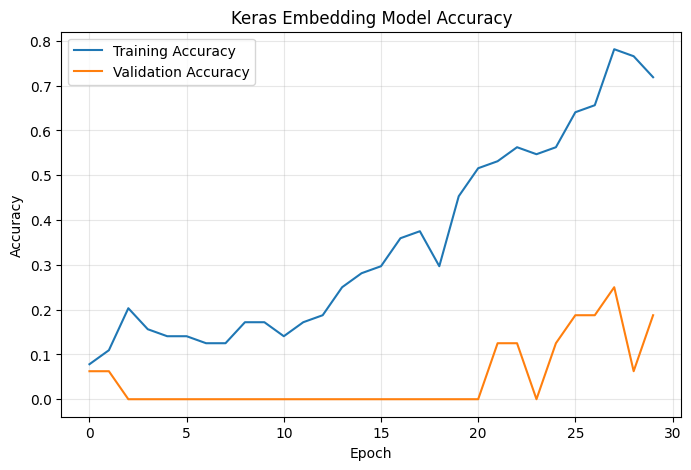

In [ ]:
# Train the Keras embedding model
history = keras_embedding_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=8,
    verbose=0
)

test_loss, test_accuracy = keras_embedding_model.evaluate(X_test, y_test, verbose=0)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

# Plot training history
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Keras Embedding Model Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# Extract Keras embedding matrix
keras_embedding_layer = keras_embedding_model.get_layer("word_embedding")
keras_embedding_matrix = keras_embedding_layer.get_weights()[0]

vocabulary = vectorizer.get_vocabulary()

print("Keras embedding matrix shape:", keras_embedding_matrix.shape)
print("First 15 vocabulary words:", vocabulary[:15])


Keras embedding matrix shape: (369, 64)
First 15 vocabulary words: ['', '[UNK]', np.str_('and'), np.str_('data'), np.str_('to'), np.str_('can'), np.str_('in'), np.str_('learning'), np.str_('words'), np.str_('language'), np.str_('is'), np.str_('from'), np.str_('word'), np.str_('training'), np.str_('systems')]


## 9. BERT Contextual Embeddings


In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME)
bert_model.eval()

print("Loaded:", MODEL_NAME)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: bert-base-uncased


In [ ]:
def get_bert_token_embedding(sentence, target_word):
    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        return_offsets_mapping=True
    )

    offset_mapping = inputs.pop("offset_mapping")

    with torch.no_grad():
        outputs = bert_model(**inputs)

    hidden_states = outputs.last_hidden_state[0]

    # Locate target word in the original sentence.
    target_start = sentence.lower().find(target_word.lower())
    target_end = target_start + len(target_word)

    selected_vectors = []
    selected_tokens = []

    for idx, (start, end) in enumerate(offset_mapping[0].tolist()):
        # Ignore special tokens.
        if start == end:
            continue

        # Token overlaps target word.
        if start < target_end and end > target_start:
            selected_vectors.append(hidden_states[idx].numpy())
            selected_tokens.append(tokenizer.convert_ids_to_tokens(inputs["input_ids"][0][idx].item()))

    if not selected_vectors:
        raise ValueError(f"Could not locate '{target_word}' in the tokenization.")

    # Average subword vectors if the word is split into multiple tokens.
    vector = np.mean(selected_vectors, axis=0)
    return vector, selected_tokens


sentence_1 = "I deposited money in the bank."
sentence_2 = "We sat beside the bank of the river."

bank_vector_1, tokens_1 = get_bert_token_embedding(sentence_1, "bank")
bank_vector_2, tokens_2 = get_bert_token_embedding(sentence_2, "bank")

context_similarity = cosine_similarity(
    bank_vector_1.reshape(1, -1),
    bank_vector_2.reshape(1, -1)
)[0][0]

print("Sentence 1:", sentence_1)
print("BERT tokens for bank:", tokens_1)

print("\nSentence 2:", sentence_2)
print("BERT tokens for bank:", tokens_2)

print(f"\nCosine similarity between the two contextual 'bank' embeddings: {context_similarity:.4f}")
print("The representations differ because BERT uses surrounding context.")


Sentence 1: I deposited money in the bank.
BERT tokens for bank: ['bank']

Sentence 2: We sat beside the bank of the river.
BERT tokens for bank: ['bank']

Cosine similarity between the two contextual 'bank' embeddings: 0.5121
The representations differ because BERT uses surrounding context.


## 10. Static vs Contextual Representation


In [ ]:
# Static vs Contextual Representation
# Word2Vec and BERT are different embedding spaces, so their raw vectors
# must NOT be compared directly with cosine similarity.

static_word = "language"

if static_word in skipgram_model.wv:
    static_vector = skipgram_model.wv[static_word]
    print(f"Word2Vec representation for '{static_word}':")
    print("Embedding dimension:", len(static_vector))
    print("First 20 values:", static_vector[:20])
else:
    print(f"'{static_word}' is not present in the Word2Vec vocabulary.")

print("\nStatic vs Contextual Representation")
print("-" * 60)
print("Word2Vec: one fixed/static vector is learned for a word.")
print("BERT: the representation changes according to surrounding context.")
print(f"BERT 'bank' context-to-context cosine similarity: {context_similarity:.4f}")
print("BERT contextual vector dimension:", len(bank_vector_1))

Word2Vec representation for 'language':
Embedding dimension: 100
First 20 values: [ 0.05745174  0.1592196  -0.16929549 -0.04272424 -0.07407687  0.18201505
  0.10972968  0.02863445 -0.30619636 -0.08126088 -0.16922761  0.12951265
  0.00562813  0.2524634  -0.1026404  -0.21934359  0.06236557 -0.22057053
 -0.10906529 -0.1147768 ]

Static vs Contextual Representation
------------------------------------------------------------
Word2Vec: one fixed/static vector is learned for a word.
BERT: the representation changes according to surrounding context.
BERT 'bank' context-to-context cosine similarity: 0.5121
BERT contextual vector dimension: 768


## 11. PCA Visualization of Word2Vec Embeddings


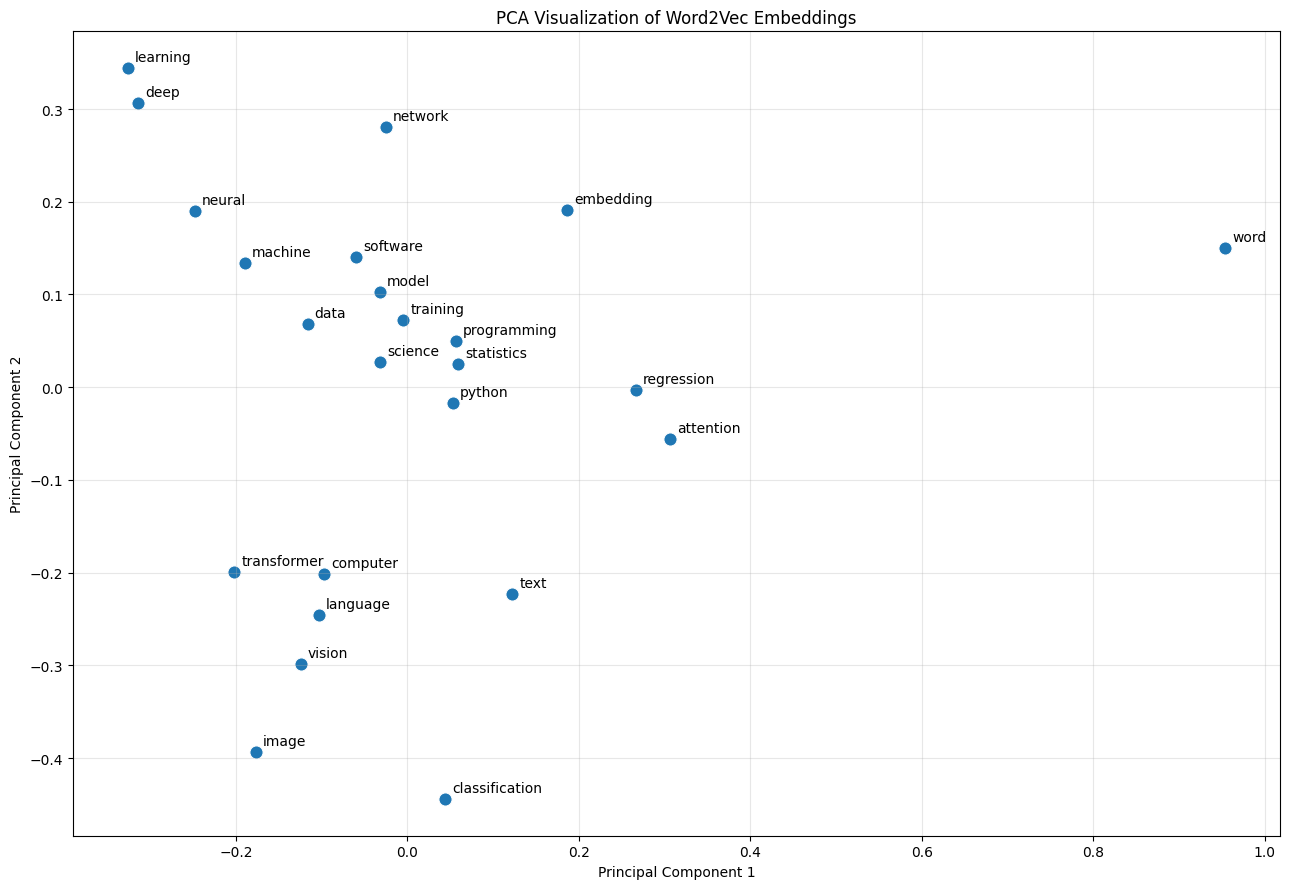

Explained variance ratio: [0.27490607 0.19008113]


In [ ]:
# Select representative words
visual_words = [
    "machine", "learning", "data", "model", "training",
    "neural", "network", "deep", "language", "text",
    "word", "embedding", "transformer", "attention",
    "computer", "software", "algorithm", "image",
    "vision", "python", "programming", "database",
    "science", "statistics", "classification", "regression"
]

visual_words = [w for w in visual_words if w in skipgram_model.wv]

vectors = np.array([skipgram_model.wv[w] for w in visual_words])

pca = PCA(n_components=2, random_state=42)
vectors_2d = pca.fit_transform(vectors)

pca_df = pd.DataFrame({
    "word": visual_words,
    "PC1": vectors_2d[:, 0],
    "PC2": vectors_2d[:, 1]
})

plt.figure(figsize=(13, 9))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", s=90)

for _, row in pca_df.iterrows():
    plt.annotate(
        row["word"],
        (row["PC1"], row["PC2"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10
    )

plt.title("PCA Visualization of Word2Vec Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("word2vec_pca_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


## 12. t-SNE Visualization


In [ ]:
# t-SNE visualization of the same Word2Vec words
visual_words = [
    "machine","learning","data","model","training","neural","network",
    "deep","language","text","word","embedding","transformer","attention",
    "computer","software","algorithm","image","vision","python",
    "programming","database","science","statistics","classification","regression"
]
visual_words = [w for w in visual_words if w in skipgram_model.wv]

visual_vectors = np.array([skipgram_model.wv[w] for w in visual_words])
perplexity = max(5, min(15, len(visual_words)-1))

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=SEED,
    init="pca",
    learning_rate="auto"
)
tsne_2d = tsne.fit_transform(visual_vectors)

plt.figure(figsize=(14, 9))
plt.scatter(tsne_2d[:,0], tsne_2d[:,1], s=80)

for i, word in enumerate(visual_words):
    plt.annotate(word, (tsne_2d[i,0], tsne_2d[i,1]),
                 xytext=(5,5), textcoords="offset points", fontsize=9)

plt.title("t-SNE Visualization of Word2Vec Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("word2vec_tsne_visualization.png", dpi=300, bbox_inches="tight")
plt.show()


NameError: name 'TSNE' is not defined

## 13. TensorFlow Embedding Projector Files


In [ ]:
from pathlib import Path

projector_dir = Path("embedding_projector")
projector_dir.mkdir(exist_ok=True)

projector_words = visual_words
projector_vectors = np.array([skipgram_model.wv[w] for w in projector_words])

np.savetxt(projector_dir / "vectors.tsv", projector_vectors, delimiter="\t")

with open(projector_dir / "metadata.tsv", "w", encoding="utf-8") as f:
    for word in projector_words:
        f.write(word + "\n")

print("Created:", projector_dir / "vectors.tsv")
print("Created:", projector_dir / "metadata.tsv")
print("Upload both files to the TensorFlow Embedding Projector if required.")


Created: embedding_projector/vectors.tsv
Created: embedding_projector/metadata.tsv
Upload both files to the TensorFlow Embedding Projector if required.


## 14. Additional Cosine Similarity Demonstration


In [ ]:
pairs = [
    ("machine", "learning"),
    ("neural", "network"),
    ("word", "embedding"),
    ("computer", "software"),
    ("language", "text")
]

pair_results = []

for w1, w2 in pairs:
    v1 = skipgram_model.wv[w1].reshape(1, -1)
    v2 = skipgram_model.wv[w2].reshape(1, -1)
    score = cosine_similarity(v1, v2)[0][0]

    pair_results.append({
        "word_1": w1,
        "word_2": w2,
        "cosine_similarity": score
    })

pair_df = pd.DataFrame(pair_results)
display(pair_df)


,word_1,word_2,cosine_similarity
0,machine,learning,0.965859
1,neural,network,0.955918
2,word,embedding,0.818797
3,computer,software,0.892881
4,language,text,0.875518


## 15. Comparative Analysis



In [ ]:
# Complete comparison required for the report
comparison = pd.DataFrame([
    ["One-Hot", "Traditional", "Sparse", "Very Low", "No", "Poor", "Very Low"],
    ["BoW", "Frequency", "Sparse", "Low", "No", "Poor", "Low"],
    ["N-grams", "Frequency", "Sparse", "Low-Moderate", "No", "Poor", "Low-Moderate"],
    ["TF-IDF", "Statistical", "Sparse", "Moderate", "No", "Poor", "Low"],
    ["Co-occurrence + LSA", "Matrix-based", "Dense after reduction", "Moderate", "No", "Limited", "Moderate"],
    ["Word2Vec", "Predictive", "Dense", "High", "No", "Poor", "Medium"],
    ["GloVe", "Global / pretrained", "Dense", "High", "No", "Poor", "Medium"],
    ["FastText", "Subword", "Dense", "High", "No", "Good", "Medium"],
    ["Keras Embedding", "Neural", "Dense", "High", "Limited", "Vocabulary-dependent", "Medium"],
    ["BERT", "Transformer", "Dense", "Very High", "Yes", "Good via subwords", "High"],
    ["SBERT", "Transformer", "Dense", "Very High", "Yes", "Good via subwords", "High"],
], columns=[
    "Technique",
    "Type",
    "Vector Form",
    "Semantic Representation",
    "Contextual Understanding",
    "OOV Handling",
    "Computational Requirement"
])

display(comparison)
comparison.to_csv("complete_embedding_comparison.csv", index=False)
print("Saved: complete_embedding_comparison.csv")


,Technique,Type,Vector Form,Semantic Representation,Contextual Understanding,OOV Handling,Computational Requirement
0,One-Hot,Traditional,Sparse,Very Low,No,Poor,Very Low
1,BoW,Frequency,Sparse,Low,No,Poor,Low
2,N-grams,Frequency,Sparse,Low-Moderate,No,Poor,Low-Moderate
3,TF-IDF,Statistical,Sparse,Moderate,No,Poor,Low
4,Co-occurrence + LSA,Matrix-based,Dense after reduction,Moderate,No,Limited,Moderate
5,Word2Vec,Predictive,Dense,High,No,Poor,Medium
6,GloVe,Global / pretrained,Dense,High,No,Poor,Medium
7,FastText,Subword,Dense,High,No,Good,Medium
8,Keras Embedding,Neural,Dense,High,Limited,Vocabulary-dependent,Medium
9,BERT,Transformer,Dense,Very High,Yes,Good via subwords,High


Saved: complete_embedding_comparison.csv
